# =============================================================================
# 01_PREPROCESSING.IPYNB
# Curățare, Filtrare și Pregătire Date pentru Analiză
# 
# Disertație de Master - Facultatea de Sociologie și Asistență Socială, UBB Cluj-Napoca
# Masterand: Răzvan-Andrei Enache
# Tema: Analiza Discursului Electoral pe YouTube (2025)
# =============================================================================

# 1. Import Configurări și Librării

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

from config import *

print("✅ Toate librăriile și configurațiile au fost încărcate cu succes.")

✅ CONFIGURARE GLOBALĂ ÎNCĂRCATĂ CU SUCCES
✅ Toate librăriile și configurațiile au fost încărcate cu succes.


# 2. Încărcare Date Raw

In [2]:
print("=" * 70)
print("ÎNCĂRCARE DATE RAW")
print("=" * 70)

# Verify files exist
if not FILE_COMMENTS_RAW.exists():
    raise FileNotFoundError(f"Fișierul comentarii nu a fost găsit: {FILE_COMMENTS_RAW}")
if not FILE_METADATA_RAW.exists():
    raise FileNotFoundError(f"Fișierul metadata nu a fost găsit: {FILE_METADATA_RAW}")

print(f"\n📁 Fișier comentarii: {FILE_COMMENTS_RAW}")
print(f"📁 Fișier metadata: {FILE_METADATA_RAW}")

# Load datasets
# Load datasets
print("\n⏳ Se încarcă datele...")
df_comments_raw = pd.read_csv(FILE_COMMENTS_RAW)
df_metadata_raw = pd.read_csv(FILE_METADATA_RAW)

print(f"\n✅ Date încărcate cu succes!")
print(f"   Comentarii: {df_comments_raw.shape[0]:,} rânduri × {df_comments_raw.shape[1]} coloane")
print(f"   Metadata: {df_metadata_raw.shape[0]:,} rânduri × {df_metadata_raw.shape[1]} coloane")

ÎNCĂRCARE DATE RAW

📁 Fișier comentarii: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\data\raw\yt_raw_comments.csv
📁 Fișier metadata: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\data\raw\yt_raw_metadata.csv

⏳ Se încarcă datele...

✅ Date încărcate cu succes!
   Comentarii: 35,786 rânduri × 7 coloane
   Metadata: 88 rânduri × 8 coloane


# 3. Standardizare Coloane

In [3]:
print("\n" + "=" * 70)
print("STANDARDIZARE COLOANE")
print("=" * 70)

# Create copies
df_comments = df_comments_raw.copy()
df_metadata = df_metadata_raw.copy()

# Rename columns using mapping
df_comments = df_comments.rename(columns=COMMENTS_COLUMN_MAP)
df_metadata = df_metadata.rename(columns=METADATA_COLUMN_MAP)

print(f"\n✅ Coloane standardizate!")
print(f"\nComentarii ({len(df_comments.columns)} coloane):")
print(f"  {df_comments.columns.tolist()}")
print(f"\nMetadata ({len(df_metadata.columns)} coloane):")
print(f"  {df_metadata.columns.tolist()}")

# Convert numeric columns
print("\n🔢 Convertire coloane numerice...")
for col in ['comment_likes', 'replies']:
    if col in df_comments.columns:
        df_comments[col] = pd.to_numeric(df_comments[col], errors='coerce').fillna(0)

for col in ['video_views', 'video_likes', 'video_comment_count', 'spam_filtered']:
    if col in df_metadata.columns:
        df_metadata[col] = pd.to_numeric(df_metadata[col], errors='coerce')

# Convert boolean columns
if 'is_creator' in df_comments.columns:
    df_comments['is_creator'] = df_comments['is_creator'].astype(str).str.strip().str.lower().isin(['true', '1', 'yes'])

if 'spam_filtered' in df_metadata.columns:
    df_metadata['spam_filtered'] = df_metadata['spam_filtered'].astype(int)

# Convert datetime columns
print("📅 Convertire coloane datetime...")
if 'comment_date' in df_comments.columns:
    df_comments['comment_date'] = pd.to_datetime(df_comments['comment_date'], errors='coerce', utc=True)
if 'video_date' in df_metadata.columns:
    df_metadata['video_date'] = pd.to_datetime(df_metadata['video_date'], errors='coerce', utc=True)

print("✅ Conversii complete!")


STANDARDIZARE COLOANE

✅ Coloane standardizate!

Comentarii (7 coloane):
  ['video_id', 'author_name', 'comment_text', 'comment_date', 'comment_likes', 'replies', 'is_creator']

Metadata (8 coloane):
  ['video_id', 'video_title', 'video_date', 'video_views', 'video_likes', 'video_comment_count', 'video_url', 'spam_filtered']

🔢 Convertire coloane numerice...
📅 Convertire coloane datetime...
✅ Conversii complete!


# 4. Audit Date Raw

In [4]:
print("\n" + "=" * 70)
print("AUDIT DATE RAW")
print("=" * 70)

def audit_dataframe(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Generează raport de audit pentru un DataFrame."""
    audit = {
        'Dataset': name,
        'Total Rânduri': len(df),
        'Total Coloane': df.shape[1],
        'Duplicate Exacte': int(df.duplicated().sum()),
        'Celule Lipsă': int(df.isna().sum().sum()),
        'Rânduri cu Lipsuri': int(df.isna().any(axis=1).sum())
    }
    return pd.DataFrame([audit])

# Audit comments
audit_comments = audit_dataframe(df_comments, 'Comentarii')
audit_metadata = audit_dataframe(df_metadata, 'Metadata')

audit_report = pd.concat([audit_comments, audit_metadata], ignore_index=True)
print("\n📊 Raport Audit:")
print(audit_report.to_string(index=False))

# Missing values breakdown for comments
print("\n🔍 Valori lipsă în comentarii (coloane cu >0 lipsuri):")
missing_comments = df_comments.isna().sum()
missing_comments = missing_comments[missing_comments > 0]
if len(missing_comments) > 0:
    missing_df = pd.DataFrame({
        'Coloană': missing_comments.index,
        'Lipsuri': missing_comments.values,
        '%': (missing_comments.values / len(df_comments) * 100).round(2)
    })
    print(missing_df.to_string(index=False))
else:
    print("  Nu există valori lipsă!")


AUDIT DATE RAW

📊 Raport Audit:
   Dataset  Total Rânduri  Total Coloane  Duplicate Exacte  Celule Lipsă  Rânduri cu Lipsuri
Comentarii          35786              7              1039            17                  17
  Metadata             88              8                 1             0                   0

🔍 Valori lipsă în comentarii (coloane cu >0 lipsuri):
     Coloană  Lipsuri    %
comment_text       17 0.05


# 5. Merge Comentarii + Metadata

In [5]:
print("\n" + "=" * 70)
print("MERGE COMENTARII + METADATA")
print("=" * 70)

# Merge on video_id
print("\n⏳ Se realizează merge pe video_id...")
df_merged = df_comments.merge(df_metadata, on='video_id', how='left')

print(f"✅ Merge completat!")
print(f"   Dataset rezultat: {df_merged.shape[0]:,} rânduri × {df_merged.shape[1]} coloane")

# Check for comments without metadata
no_metadata = df_merged['video_title'].isna().sum()
if no_metadata > 0:
    print(f"\n⚠️  Atenție: {no_metadata:,} comentarii fără metadata asociată")
    print("   Acestea vor fi păstrate pentru analiză.")

# === DEBUG: Verifică duplicate din metadata ===
print(f"\n🔍 DEBUG: df_comments rows = {len(df_comments):,}")
print(f"🔍 DEBUG: df_merged rows = {len(df_merged):,}")
print(f"🔍 DEBUG: Diferență = {len(df_merged) - len(df_comments):,}")

if len(df_merged) > len(df_comments):
    print(f"\n⚠️  ATENȚIE: Merge-ul a creat rânduri suplimentare!")
    print(f"   Cauza probabilă: video_id duplicate în metadata")
    
    # Verifică duplicate în metadata
    dupes_in_metadata = df_metadata['video_id'].duplicated().sum()
    print(f"   Video ID duplicate în metadata: {dupes_in_metadata:,}")

# === SETEAZĂ INITIAL_COUNT DUPĂ MERGE (CORECT!) ===
initial_count = len(df_merged)
print(f"\n🔍 initial_count setat la: {initial_count:,} (după merge)")

# === INIȚIALIZEAZĂ PIPELINE REMOVALS ===
pipeline_removals = {
    'spam_creator': 0,
    'temporal': 0,
    'text_cleaning': 0,
    'quality_filter': 0,
    'deduplication': 0
}
print(f"🔍 pipeline_removals inițializat: {pipeline_removals}")



MERGE COMENTARII + METADATA

⏳ Se realizează merge pe video_id...
✅ Merge completat!
   Dataset rezultat: 37,858 rânduri × 14 coloane

🔍 DEBUG: df_comments rows = 35,786
🔍 DEBUG: df_merged rows = 37,858
🔍 DEBUG: Diferență = 2,072

⚠️  ATENȚIE: Merge-ul a creat rânduri suplimentare!
   Cauza probabilă: video_id duplicate în metadata
   Video ID duplicate în metadata: 1

🔍 initial_count setat la: 37,858 (după merge)
🔍 pipeline_removals inițializat: {'spam_creator': 0, 'temporal': 0, 'text_cleaning': 0, 'quality_filter': 0, 'deduplication': 0}


# 6. Filtru Spam și Creator

In [6]:
print("\n" + "=" * 70)
print("FILTRU SPAM ȘI CREATOR")
print("=" * 70)

initial_count_step = len(df_merged)

# Filter spam videos
if EXCLUDE_SPAM and 'spam_filtered' in df_merged.columns:
    spam_count = (df_merged['spam_filtered'] == 1).sum()
    df_merged = df_merged[df_merged['spam_filtered'] != 1].copy()
else:
    spam_count = 0

# Filter creator comments
if EXCLUDE_CREATOR_COMMENTS and 'is_creator' in df_merged.columns:
    creator_count = (df_merged['is_creator'] == True).sum()
    df_merged = df_merged[df_merged['is_creator'] != True].copy()
else:
    creator_count = 0

# Track removals - CORECTAT
pipeline_removals['spam_creator'] = spam_count + creator_count

final_count_step = len(df_merged)
removed_count = initial_count_step - final_count_step

# === DEBUG ===
print(f"\n🔍 DEBUG: initial_count_step = {initial_count_step:,}")
print(f"🔍 DEBUG: final_count_step = {final_count_step:,}")
print(f"🔍 DEBUG: removed_count = {removed_count:,}")
print(f"🔍 DEBUG: spam_count + creator_count = {spam_count + creator_count:,}")
print(f"🔍 DEBUG: Potrivire: {removed_count == spam_count + creator_count}")
# ==============

print(f"\n📊 Rezultat filtrare:")
print(f"   Inițial: {initial_count_step:,} comentarii")
print(f"   Final: {final_count_step:,} comentarii")
print(f"   Eliminate: {removed_count:,} ({removed_count/initial_count_step*100:.1f}%)")



FILTRU SPAM ȘI CREATOR

🔍 DEBUG: initial_count_step = 37,858
🔍 DEBUG: final_count_step = 37,841
🔍 DEBUG: removed_count = 17
🔍 DEBUG: spam_count + creator_count = 17
🔍 DEBUG: Potrivire: True

📊 Rezultat filtrare:
   Inițial: 37,858 comentarii
   Final: 37,841 comentarii
   Eliminate: 17 (0.0%)


# 7. Filtru Temporal (Perioada Turul 2)

In [7]:
print("\n" + "=" * 70)
print("FILTRU TEMPORAL (PERIOADA TURUL 2)")
print("=" * 70)

print(f"\n📅 Perioadă țintă: {DATE_START} până la {DATE_END}")

# Convert comment_date to datetime if not already
if df_merged['comment_date'].dtype != 'datetime64[ns, UTC]':
    df_merged['comment_date'] = pd.to_datetime(df_merged['comment_date'], errors='coerce', utc=True)

# === DEBUG: Înainte de filtru ===
print(f"\n🔍 DEBUG: len(df_merged) ÎNAINTE filtru temporal = {len(df_merged):,}")

# Filter by date range
pre_temporal = len(df_merged)
df_merged = df_merged[
    (df_merged['comment_date'] >= DATE_START) & 
    (df_merged['comment_date'] <= DATE_END)
].copy()
post_temporal = len(df_merged)
removed_temporal = pre_temporal - post_temporal

# === DEBUG: După filtru ===
print(f"🔍 DEBUG: len(df_merged) DUPĂ filtru temporal = {len(df_merged):,}")
print(f"🔍 DEBUG: pre_temporal = {pre_temporal:,}")
print(f"🔍 DEBUG: post_temporal = {post_temporal:,}")
print(f"🔍 DEBUG: removed_temporal = {removed_temporal:,}")

# Track removals
pipeline_removals['temporal'] = removed_temporal

print(f"\n🗑️  Eliminate comentarii în afara perioadei: {removed_temporal:,} ({removed_temporal/pre_temporal*100:.1f}%)")
print(f"   Rămân: {post_temporal:,} comentarii")

# Show date distribution
if len(df_merged) > 0:
    print(f"\n📊 Distribuție temporală:")
    print(f"   Data minimă: {df_merged['comment_date'].min()}")
    print(f"   Data maximă: {df_merged['comment_date'].max()}")
    print(f"   Zile acoperite: {(df_merged['comment_date'].max() - df_merged['comment_date'].min()).days + 1}")



FILTRU TEMPORAL (PERIOADA TURUL 2)

📅 Perioadă țintă: 2025-05-01 până la 2025-05-18

🔍 DEBUG: len(df_merged) ÎNAINTE filtru temporal = 37,841
🔍 DEBUG: len(df_merged) DUPĂ filtru temporal = 20,357
🔍 DEBUG: pre_temporal = 37,841
🔍 DEBUG: post_temporal = 20,357
🔍 DEBUG: removed_temporal = 17,484

🗑️  Eliminate comentarii în afara perioadei: 17,484 (46.2%)
   Rămân: 20,357 comentarii

📊 Distribuție temporală:
   Data minimă: 2025-05-01 04:46:20+00:00
   Data maximă: 2025-05-17 23:56:03+00:00
   Zile acoperite: 17


# 8. Curățare Text

In [8]:
print("\n" + "=" * 70)
print("CURĂȚARE TEXT")
print("=" * 70)

def clean_text(text: str) -> str:
    """
    Curăță textul comentariului:
    - Remove URLs
    - Remove HTML tags
    - Remove mentions (@username)
    - Normalize whitespace
    - Keep Emojis (valoare sentimentală)
    """
    if pd.isna(text):
        return ''
    
    t = str(text)
    
    # Remove URLs
    t = re.sub(r'http\S+|www\.\S+', ' ', t)
    
    # Remove HTML tags
    t = re.sub(r'<[^>]+>', ' ', t)
    
    # Remove mentions
    t = re.sub(r'@\w+', ' ', t)
    
    # Normalize whitespace
    t = re.sub(r'\s+', ' ', t).strip()
    
    return t

print("\n⏳ Se curăță textul comentariilor...")
df_merged['clean_text'] = df_merged['comment_text'].apply(clean_text)
print("✅ Curățare text completă!")

# Remove empty comments after cleaning
pre_clean = len(df_merged)
df_merged = df_merged[df_merged['clean_text'].str.len() > 0].copy()
post_clean = len(df_merged)
removed_clean = pre_clean - post_clean

# Track removals
pipeline_removals['text_cleaning'] = removed_clean

print(f"\n🗑️  Eliminate comentarii goale după curățare: {removed_clean:,}")

# Count emoji per comment
print("\n📊 Calcul count emoji per comentariu...")
emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF"
    "\U00002702-\U000027B0"
    "\U000024C2-\U0001F251"
    "]+",
    flags=re.UNICODE
)
df_merged['emoji_count'] = df_merged['clean_text'].apply(
    lambda x: len(emoji_pattern.findall(x)) if pd.notna(x) else 0
)

print(f"   Comentarii cu emoji: {(df_merged['emoji_count'] > 0).sum():,} ({(df_merged['emoji_count'] > 0).mean()*100:.1f}%)")
print(f"   Emoji count - Mean: {df_merged['emoji_count'].mean():.2f}, Median: {df_merged['emoji_count'].median():.0f}")


CURĂȚARE TEXT

⏳ Se curăță textul comentariilor...
✅ Curățare text completă!

🗑️  Eliminate comentarii goale după curățare: 34

📊 Calcul count emoji per comentariu...
   Comentarii cu emoji: 4,883 (24.0%)
   Emoji count - Mean: 0.30, Median: 0


# 9. Filtru Calitate (Lungime Minimă)

In [9]:
print("\n" + "=" * 70)
print("FILTRU CALITATE (LUNGIME MINIMĂ)")
print("=" * 70)

# Calculate word count and char length
print("\n📏 Calcul lungime text...")
df_merged['word_count'] = df_merged['clean_text'].apply(calculate_word_count)
df_merged['char_len'] = df_merged['clean_text'].apply(calculate_text_length)

print(f"\n📊 Statistici lungime text:")
print(f"   Word count - Mean: {df_merged['word_count'].mean():.1f}, Median: {df_merged['word_count'].median():.0f}")
print(f"   Char length - Mean: {df_merged['char_len'].mean():.0f}, Median: {df_merged['char_len'].median():.0f}")

# Apply minimum filters
pre_filter = len(df_merged)

print(f"\n🔍 Aplicare filtre calitate:")
print(f"   Min word count: {MIN_WORD_COUNT}")
print(f"   Min char length: {MIN_CHAR_LENGTH}")

df_merged = df_merged[
    (df_merged['word_count'] >= MIN_WORD_COUNT) & 
    (df_merged['char_len'] >= MIN_CHAR_LENGTH)
].copy()

post_filter = len(df_merged)
removed_filter = pre_filter - post_filter

# Track removals
pipeline_removals['quality_filter'] = removed_filter

print(f"\n🗑️  Eliminate comentarii sub pragul minim: {removed_filter:,} ({removed_filter/pre_filter*100:.1f}%)")
print(f"   Rămân: {post_filter:,} comentarii")


FILTRU CALITATE (LUNGIME MINIMĂ)

📏 Calcul lungime text...

📊 Statistici lungime text:
   Word count - Mean: 24.1, Median: 12
   Char length - Mean: 136, Median: 70

🔍 Aplicare filtre calitate:
   Min word count: 5
   Min char length: 20

🗑️  Eliminate comentarii sub pragul minim: 4,296 (21.1%)
   Rămân: 16,027 comentarii


# 10. Eliminare Duplicate

In [10]:
print("\n" + "=" * 70)
print("ELIMINARE DUPLICATE")
print("=" * 70)

pre_dedupe = len(df_merged)

# Remove exact duplicates based on video_id + author_name + clean_text
df_merged = df_merged.drop_duplicates(
    subset=['video_id', 'author_name', 'clean_text'],
    keep='first'
).copy()

post_dedupe = len(df_merged)
removed_dupes = pre_dedupe - post_dedupe

# Track removals
pipeline_removals['deduplication'] = removed_dupes

print(f"\n🗑️  Duplicate eliminate: {removed_dupes:,}")
print(f"   Rămân: {post_dedupe:,} comentarii unice")


ELIMINARE DUPLICATE

🗑️  Duplicate eliminate: 1,417
   Rămân: 14,610 comentarii unice


# 11. Calcul Metrici Lingvistice (pentru RQ3)


CALCUL METRICI LINGVISTICE (PENTRU RQ3)

⏳ Se calculează markerii lingvistici agresivi...
✅ Metrici calculate!

📊 Statistici metrici lingvistice:
   Caps ratio - Mean: 0.0531, Median: 0.0000
   Aggressive punct - Mean: 0.73, Median: 0

💾 Grafic salvat: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\dissertation_outputs\linguistic_metrics_distribution.png


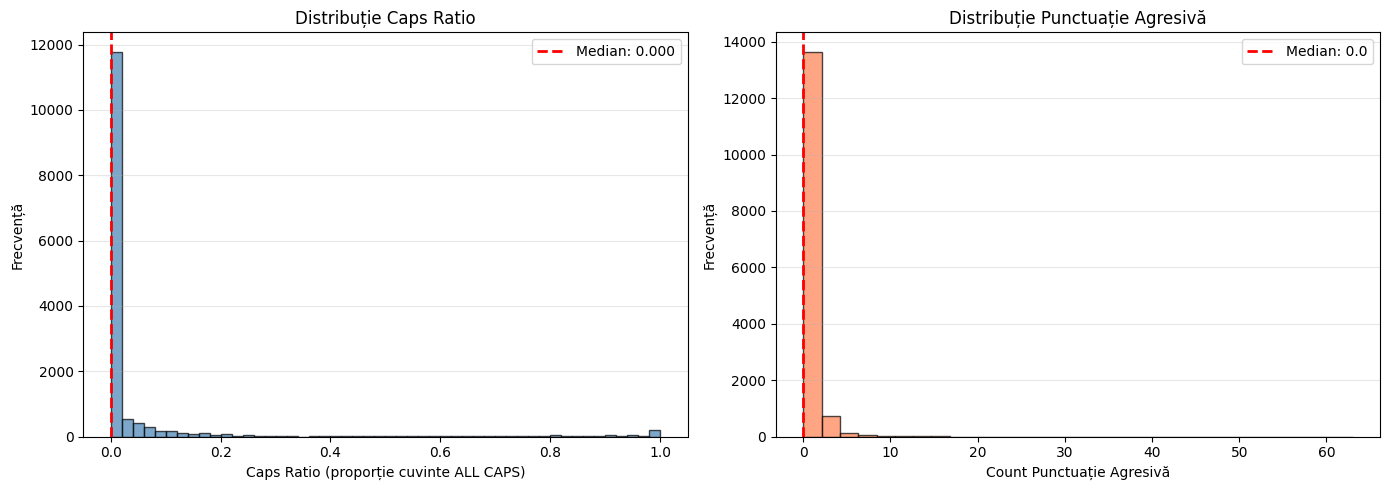

In [11]:
print("\n" + "=" * 70)
print("CALCUL METRICI LINGVISTICE (PENTRU RQ3)")
print("=" * 70)

print("\n⏳ Se calculează markerii lingvistici agresivi...")

# Caps ratio
df_merged['caps_ratio'] = df_merged['clean_text'].apply(calculate_caps_ratio)

# Aggressive punctuation
df_merged['aggressive_punct'] = df_merged['clean_text'].apply(count_aggressive_punctuation)

print("✅ Metrici calculate!")

print(f"\n📊 Statistici metrici lingvistice:")
print(f"   Caps ratio - Mean: {df_merged['caps_ratio'].mean():.4f}, Median: {df_merged['caps_ratio'].median():.4f}")
print(f"   Aggressive punct - Mean: {df_merged['aggressive_punct'].mean():.2f}, Median: {df_merged['aggressive_punct'].median():.0f}")

# Distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Caps ratio distribution
axes[0].hist(df_merged['caps_ratio'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Caps Ratio (proporție cuvinte ALL CAPS)')
axes[0].set_ylabel('Frecvență')
axes[0].set_title('Distribuție Caps Ratio')
axes[0].axvline(df_merged['caps_ratio'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {df_merged["caps_ratio"].median():.3f}')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Aggressive punctuation distribution
axes[1].hist(df_merged['aggressive_punct'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Count Punctuație Agresivă')
axes[1].set_ylabel('Frecvență')
axes[1].set_title('Distribuție Punctuație Agresivă')
axes[1].axvline(df_merged['aggressive_punct'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {df_merged["aggressive_punct"].median():.1f}')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_OUTPUT / 'linguistic_metrics_distribution.png', dpi=150, bbox_inches='tight')
print(f"\n💾 Grafic salvat: {DATA_OUTPUT / 'linguistic_metrics_distribution.png'}")
plt.show()

# 12. Detectare Candidați


DETECTARE CANDIDAȚI

⏳ Se atribuie comentariile candidaților...
✅ Detectare candidați completă!

📊 Distribuție mențiuni candidați:
Candidat  Count  Percentage
    none   8452       57.85
  simion   3343       22.88
     dan   1825       12.49
    both    990        6.78

💾 Grafic salvat: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\dissertation_outputs\candidate_distribution.png


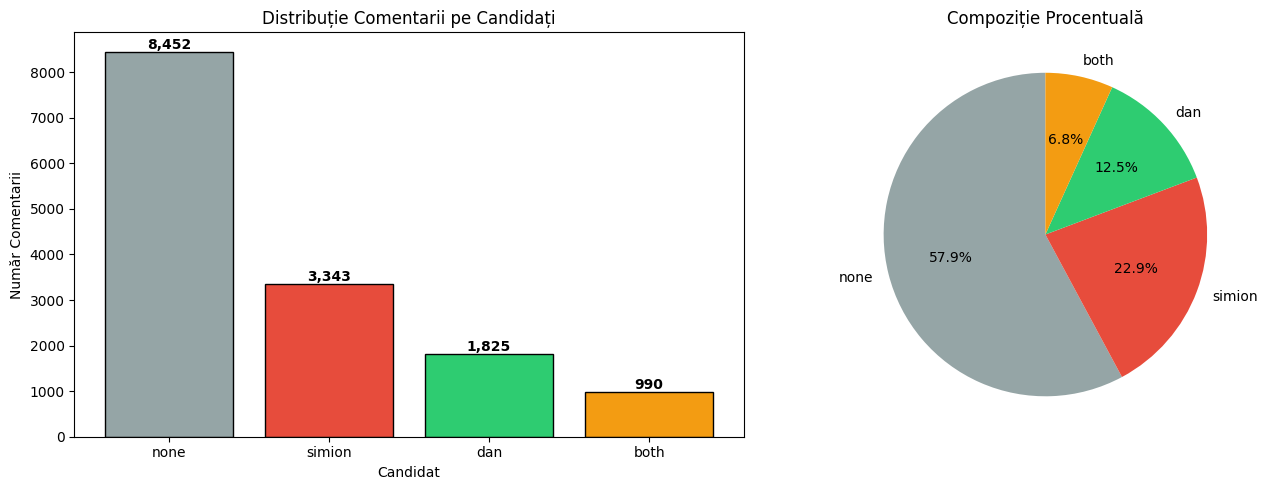

In [12]:
print("\n" + "=" * 70)
print("DETECTARE CANDIDAȚI")
print("=" * 70)

def assign_candidate(text: str) -> str:
    """
    Atribuie comentariul unui candidat pe baza keywords.
    
    Returns:
        'simion', 'dan', 'both', sau 'none'
    """
    if pd.isna(text):
        return 'none'
    
    text_lower = str(text).lower()
    
    # Check for each candidate
    mentions_simion = any(
        re.search(r'\b' + re.escape(kw) + r'\b', text_lower) 
        for kw in SIMION_KEYWORDS
    )
    mentions_dan = any(
        re.search(r'\b' + re.escape(kw) + r'\b', text_lower) 
        for kw in NICUSOR_KEYWORDS
    )
    
    if mentions_simion and mentions_dan:
        return 'both'
    elif mentions_simion:
        return 'simion'
    elif mentions_dan:
        return 'dan'
    else:
        return 'none'

print("\n⏳ Se atribuie comentariile candidaților...")
df_merged['candidate_mentioned'] = df_merged['clean_text'].apply(assign_candidate)
print("✅ Detectare candidați completă!")

# Distribution
print("\n📊 Distribuție mențiuni candidați:")
candidate_dist = df_merged['candidate_mentioned'].value_counts()
candidate_pct = df_merged['candidate_mentioned'].value_counts(normalize=True) * 100

candidate_summary = pd.DataFrame({
    'Candidat': candidate_dist.index,
    'Count': candidate_dist.values,
    'Percentage': candidate_pct.values.round(2)
})
print(candidate_summary.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#2ecc71' if c == 'dan' else '#e74c3c' if c == 'simion' else '#f39c12' if c == 'both' else '#95a5a6' 
          for c in candidate_dist.index]
axes[0].bar(range(len(candidate_dist)), candidate_dist.values, color=colors, edgecolor='black')
axes[0].set_xticks(range(len(candidate_dist)))
axes[0].set_xticklabels(candidate_dist.index, rotation=0)
axes[0].set_xlabel('Candidat')
axes[0].set_ylabel('Număr Comentarii')
axes[0].set_title('Distribuție Comentarii pe Candidați')
for i, v in enumerate(candidate_dist.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(candidate_dist.values, labels=candidate_dist.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Compoziție Procentuală')

plt.tight_layout()
plt.savefig(DATA_OUTPUT / 'candidate_distribution.png', dpi=150, bbox_inches='tight')
print(f"\n💾 Grafic salvat: {DATA_OUTPUT / 'candidate_distribution.png'}")
plt.show()

# 13. Transformări pentru RQ3 (Engagement Variables)

In [13]:
print("\n" + "=" * 70)
print("TRANSFORMĂRI PENTRU RQ3 (ENGAGEMENT VARIABLES)")
print("=" * 70)

# 0. CREARE COLOANĂ ENGAGEMENT (trebuie făcută PRIMA!)
print("\n📊 Creare coloană engagement (likes + replies)...")
df_merged['engagement'] = df_merged['comment_likes'] + df_merged['replies']
print(f"   Engagement - Mean: {df_merged['engagement'].mean():.1f}, Median: {df_merged['engagement'].median():.0f}")

# 1. Log transform pentru likes și replies
print("\n📊 Log transform pentru engagement (reduce skew)...")
df_merged['log_likes'] = np.log1p(df_merged['comment_likes'])
df_merged['log_replies'] = np.log1p(df_merged['replies'])
df_merged['log_engagement'] = np.log1p(df_merged['engagement'])

print(f"   Likes - Original: mean={df_merged['comment_likes'].mean():.1f}, median={df_merged['comment_likes'].median():.0f}")
print(f"   Likes - Log: mean={df_merged['log_likes'].mean():.3f}, median={df_merged['log_likes'].median():.3f}")
print(f"   Replies - Original: mean={df_merged['replies'].mean():.1f}, median={df_merged['replies'].median():.0f}")
print(f"   Replies - Log: mean={df_merged['log_replies'].mean():.3f}, median={df_merged['log_replies'].median():.3f}")
print(f"   Engagement - Original: mean={df_merged['engagement'].mean():.1f}, median={df_merged['engagement'].median():.0f}")
print(f"   Engagement - Log: mean={df_merged['log_engagement'].mean():.3f}, median={df_merged['log_engagement'].median():.3f}")

# 2. Winsorize / Cap la Q99 pentru grafice și statistici descriptive
print("\n📊 Cap outliers la Q99 pentru statistici descriptive...")
likes_q99 = df_merged['comment_likes'].quantile(ENGAGEMENT_Q99_CAP)
replies_q99 = df_merged['replies'].quantile(ENGAGEMENT_Q99_CAP)
engagement_q99 = df_merged['engagement'].quantile(ENGAGEMENT_Q99_CAP)

df_merged['likes_capped'] = df_merged['comment_likes'].clip(upper=likes_q99)
df_merged['replies_capped'] = df_merged['replies'].clip(upper=replies_q99)
df_merged['engagement_capped'] = df_merged['engagement'].clip(upper=engagement_q99)

print(f"   Likes Q99 cap: {likes_q99:.0f}")
print(f"   Replies Q99 cap: {replies_q99:.0f}")
print(f"   Engagement Q99 cap: {engagement_q99:.0f}")

# 3. Binary variables pentru markerii agresivi
print("\n📊 Variabile binare pentru markerii agresivi...")
df_merged['has_caps'] = (df_merged['caps_ratio'] > 0).astype(int)
df_merged['has_aggressive_punct'] = (df_merged['aggressive_punct'] > 0).astype(int)
df_merged['high_caps'] = (df_merged['caps_ratio'] > 0.10).astype(int)  # >10% caps

print(f"   Comentarii cu caps: {df_merged['has_caps'].sum():,} ({df_merged['has_caps'].mean()*100:.1f}%)")
print(f"   Comentarii cu punctuație agresivă: {df_merged['has_aggressive_punct'].sum():,} ({df_merged['has_aggressive_punct'].mean()*100:.1f}%)")
print(f"   Comentarii cu high caps (>10%): {df_merged['high_caps'].sum():,} ({df_merged['high_caps'].mean()*100:.1f}%)")

# 4. Binary variable pentru emoji
print("\n📊 Variabilă binară pentru emoji...")
df_merged['has_emoji'] = (df_merged['emoji_count'] > 0).astype(int)
print(f"   Comentarii cu emoji: {df_merged['has_emoji'].sum():,} ({df_merged['has_emoji'].mean()*100:.1f}%)")

# 5. Summary statistics pentru disertație
print("\n" + "=" * 70)
print("SUMMARY STATISTICS PENTRU RQ3 (GATA DE DISERTAȚIE)")
print("=" * 70)

summary_stats = pd.DataFrame({
    'Variabilă': ['comment_likes', 'replies', 'engagement', 'caps_ratio', 'aggressive_punct', 'emoji_count'],
    'Mean': [
        df_merged['comment_likes'].mean(),
        df_merged['replies'].mean(),
        df_merged['engagement'].mean(),
        df_merged['caps_ratio'].mean(),
        df_merged['aggressive_punct'].mean(),
        df_merged['emoji_count'].mean()
    ],
    'Median': [
        df_merged['comment_likes'].median(),
        df_merged['replies'].median(),
        df_merged['engagement'].median(),
        df_merged['caps_ratio'].median(),
        df_merged['aggressive_punct'].median(),
        df_merged['emoji_count'].median()
    ],
    'Std': [
        df_merged['comment_likes'].std(),
        df_merged['replies'].std(),
        df_merged['engagement'].std(),
        df_merged['caps_ratio'].std(),
        df_merged['aggressive_punct'].std(),
        df_merged['emoji_count'].std()
    ],
    'Q99': [
        df_merged['comment_likes'].quantile(0.99),
        df_merged['replies'].quantile(0.99),
        df_merged['engagement'].quantile(0.99),
        df_merged['caps_ratio'].quantile(0.99),
        df_merged['aggressive_punct'].quantile(0.99),
        df_merged['emoji_count'].quantile(0.99)
    ]
})

print(summary_stats.round(3).to_string(index=False))

# Save summary for dissertation
summary_stats.to_csv(DATA_OUTPUT / 'rq3_summary_stats.csv', index=False, encoding='utf-8-sig')
print(f"\n💾 Summary stats salvat: {DATA_OUTPUT / 'rq3_summary_stats.csv'}")


TRANSFORMĂRI PENTRU RQ3 (ENGAGEMENT VARIABLES)

📊 Creare coloană engagement (likes + replies)...
   Engagement - Mean: 17.4, Median: 1

📊 Log transform pentru engagement (reduce skew)...
   Likes - Original: mean=15.7, median=1
   Likes - Log: mean=1.086, median=0.693
   Replies - Original: mean=1.7, median=0
   Replies - Log: mean=0.455, median=0.000
   Engagement - Original: mean=17.4, median=1
   Engagement - Log: mean=1.230, median=0.693

📊 Cap outliers la Q99 pentru statistici descriptive...
   Likes Q99 cap: 275
   Replies Q99 cap: 26
   Engagement Q99 cap: 295

📊 Variabile binare pentru markerii agresivi...
   Comentarii cu caps: 3,282 (22.5%)
   Comentarii cu punctuație agresivă: 6,092 (41.7%)
   Comentarii cu high caps (>10%): 1,350 (9.2%)

📊 Variabilă binară pentru emoji...
   Comentarii cu emoji: 3,192 (21.8%)

SUMMARY STATISTICS PENTRU RQ3 (GATA DE DISERTAȚIE)
       Variabilă   Mean  Median     Std    Q99
   comment_likes 15.683     1.0  98.766 274.91
         replies  1.

# 14. Audit Final Pipeline

In [14]:
print("\n" + "=" * 70)
print("AUDIT FINAL PIPELINE")
print("=" * 70)

# === DEBUG: Toate variabilele ===
print(f"\n🔍 DEBUG - Toate variabilele pipeline:")
print(f"   initial_count: {initial_count:,}")
print(f"   pipeline_removals['spam_creator']: {pipeline_removals['spam_creator']:,}")
print(f"   pipeline_removals['temporal']: {pipeline_removals['temporal']:,}")
print(f"   pipeline_removals['text_cleaning']: {pipeline_removals['text_cleaning']:,}")
print(f"   pipeline_removals['quality_filter']: {pipeline_removals['quality_filter']:,}")
print(f"   pipeline_removals['deduplication']: {pipeline_removals['deduplication']:,}")
print(f"   pre_clean: {pre_clean:,}")
print(f"   post_clean: {post_clean:,}")
print(f"   post_filter: {post_filter:,}")
print(f"   post_dedupe: {post_dedupe:,}")
print(f"   len(df_merged): {len(df_merged):,}")
# ===============================

# Build pipeline summary - FOLOSEȘTE VARIABILELE DIRECT
pipeline_summary = pd.DataFrame({
    'Etapa': [
        'Raw Input',
        'After Spam/Creator Filter',
        'After Temporal Filter',
        'After Text Cleaning',
        'After Quality Filter',
        'After Deduplication',
        'Final Dataset'
    ],
    'Comentarii': [
        initial_count,
        initial_count - pipeline_removals['spam_creator'],
        post_temporal,              # ← DIRECT, nu calcul!
        post_clean,
        post_filter,
        post_dedupe,
        len(df_merged)
    ]
})

# Calculate retention rates
pipeline_summary['Retenție %'] = (
    pipeline_summary['Comentarii'] / initial_count * 100
).round(2)

print("\n📊 Pipeline Summary:")
print(pipeline_summary.to_string(index=False))

# Detailed removals breakdown
print(f"\n🔍 Detalieri Eliminări:")
for stage, count in pipeline_removals.items():
    pct = count / initial_count * 100
    print(f"   {stage}: {count:,} ({pct:.2f}%)")

print(f"\n📊 Total eliminate: {sum(pipeline_removals.values()):,} ({sum(pipeline_removals.values())/initial_count*100:.1f}%)")
print(f"   Total reținute: {len(df_merged):,} ({len(df_merged)/initial_count*100:.1f}%)")

# Check for missing values in key columns
print(f"\n🔍 Valori lipsă în coloane cheie:")
key_cols = ['clean_text', 'candidate_mentioned', 'comment_likes', 'replies', 'caps_ratio', 'aggressive_punct', 'engagement']
for col in key_cols:
    if col in df_merged.columns:
        missing = df_merged[col].isna().sum()
        pct = missing / len(df_merged) * 100
        print(f"   {col}: {missing:,} ({pct:.2f}%)")



AUDIT FINAL PIPELINE

🔍 DEBUG - Toate variabilele pipeline:
   initial_count: 37,858
   pipeline_removals['spam_creator']: 17
   pipeline_removals['temporal']: 17,484
   pipeline_removals['text_cleaning']: 34
   pipeline_removals['quality_filter']: 4,296
   pipeline_removals['deduplication']: 1,417
   pre_clean: 20,357
   post_clean: 20,323
   post_filter: 16,027
   post_dedupe: 14,610
   len(df_merged): 14,610

📊 Pipeline Summary:
                    Etapa  Comentarii  Retenție %
                Raw Input       37858      100.00
After Spam/Creator Filter       37841       99.96
    After Temporal Filter       20357       53.77
      After Text Cleaning       20323       53.68
     After Quality Filter       16027       42.33
      After Deduplication       14610       38.59
            Final Dataset       14610       38.59

🔍 Detalieri Eliminări:
   spam_creator: 17 (0.04%)
   temporal: 17,484 (46.18%)
   text_cleaning: 34 (0.09%)
   quality_filter: 4,296 (11.35%)
   deduplication: 1

# 15. Export Dataset Curățat

In [15]:
print("\n" + "=" * 70)
print("EXPORT DATASET CURĂȚAT")
print("=" * 70)

# Select columns for export
export_columns = [
    'video_id',
    'author_name',
    'comment_text',
    'clean_text',
    'comment_date',
    'comment_likes',
    'replies',
    'engagement',
    'log_likes',
    'log_replies',
    'log_engagement',
    'likes_capped',
    'replies_capped',
    'engagement_capped',
    'word_count',
    'char_len',
    'caps_ratio',
    'aggressive_punct',
    'has_caps',
    'has_aggressive_punct',
    'high_caps',
    'emoji_count',
    'has_emoji',
    'candidate_mentioned',
    'video_title',
    'video_url'
]

# Keep only existing columns
export_columns = [c for c in export_columns if c in df_merged.columns]

df_export = df_merged[export_columns].copy()

# Save to CSV
print(f"\n⏳ Se exportă dataset curățat...")
df_export.to_csv(FILE_COMMENTS_CLEANED, index=False, encoding='utf-8-sig')
print(f"✅ Export completat!")
print(f"   Fișier: {FILE_COMMENTS_CLEANED}")
print(f"   Rânduri: {len(df_export):,}")
print(f"   Coloane: {len(df_export.columns)}")

# Save pipeline summary
pipeline_summary.to_csv(DATA_PROCESSED / 'pipeline_summary.csv', index=False, encoding='utf-8-sig')
print(f"   Pipeline summary: {DATA_PROCESSED / 'pipeline_summary.csv'}")

# Save audit report
audit_final = audit_dataframe(df_export, 'Final Cleaned')
audit_final.to_csv(DATA_PROCESSED / 'audit_final.csv', index=False, encoding='utf-8-sig')
print(f"   Audit report: {DATA_PROCESSED / 'audit_final.csv'}")


EXPORT DATASET CURĂȚAT

⏳ Se exportă dataset curățat...
✅ Export completat!
   Fișier: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\data\processed\comments_cleaned.csv
   Rânduri: 14,610
   Coloane: 26
   Pipeline summary: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\data\processed\pipeline_summary.csv
   Audit report: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\data\processed\audit_final.csv


# 16. Preview Dataset Final

In [16]:
print("\n" + "=" * 70)
print("PREVIEW DATASET FINAL")
print("=" * 70)

print("\n📋 Primele 5 rânduri:")
display(df_export.head())

print("\n📊 Data types:")
print(df_export.dtypes)

print("\n📈 Statistici descriptive (coloane numerice):")
numeric_cols = df_export.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 0:
    display(df_export[numeric_cols].describe())


PREVIEW DATASET FINAL

📋 Primele 5 rânduri:


,video_id,author_name,comment_text,clean_text,comment_date,comment_likes,replies,engagement,log_likes,log_replies,log_engagement,likes_capped,replies_capped,engagement_capped,word_count,char_len,caps_ratio,aggressive_punct,has_caps,has_aggressive_punct,high_caps,emoji_count,has_emoji,candidate_mentioned,video_title,video_url
768,_AkLQ7SIiiQ,@gabrielalbu8523,Mai clar de atât nu se poate! Ff bun material.🙏,Mai clar de atât nu se poate! Ff bun material.🙏,2025-05-14 12:48:14+00:00,574,16,590,6.354370,2.833213,6.381816,274.91,16,294.91,10,47,0.000000,1,0,1,0,1,1,none,GEORGE SIMION,https://www.youtube.com/watch?v=_AkLQ7SIiiQ
769,_AkLQ7SIiiQ,@Gabriel-Anderson,Simion m-a convins sa il votez pe Nicusor Dan presedinte.,Simion m-a convins sa il votez pe Nicusor Dan presedinte.,2025-05-14 12:14:48+00:00,479,8,487,6.173786,2.197225,6.190315,274.91,8,294.91,10,57,0.000000,0,0,0,0,0,0,both,GEORGE SIMION,https://www.youtube.com/watch?v=_AkLQ7SIiiQ
770,_AkLQ7SIiiQ,@marietafica5504,Un influencer prezent si cu spirit civic. multumim,Un influencer prezent si cu spirit civic. multumim,2025-05-14 13:23:53+00:00,426,6,432,6.056784,1.945910,6.070738,274.91,6,294.91,8,50,0.000000,0,0,0,0,0,0,none,GEORGE SIMION,https://www.youtube.com/watch?v=_AkLQ7SIiiQ
771,_AkLQ7SIiiQ,@Mihai_TPN,"Multumim pentru video, sper sa nu il dea abuziv AEP jos - asa cum face zilele astea pe TikTok","Multumim pentru video, sper sa nu il dea abuziv AEP jos - asa cum face zilele astea pe TikTok",2025-05-14 12:29:55+00:00,326,9,335,5.789960,2.302585,5.817111,274.91,9,294.91,19,93,0.052632,0,1,0,0,0,0,none,GEORGE SIMION,https://www.youtube.com/watch?v=_AkLQ7SIiiQ
772,_AkLQ7SIiiQ,@Tyrant1126,"Nu mi mai fac griji. O sa castige, Nicusor, dar o sa avem o divizare in societate cum nu am avut...","Nu mi mai fac griji. O sa castige, Nicusor, dar o sa avem o divizare in societate cum nu am avut...",2025-05-14 15:26:33+00:00,269,29,298,5.598422,3.401197,5.700444,269.00,26,294.91,41,237,0.024390,2,1,1,0,0,0,dan,GEORGE SIMION,https://www.youtube.com/watch?v=_AkLQ7SIiiQ



📊 Data types:
video_id                                str
author_name                             str
comment_text                            str
clean_text                              str
comment_date            datetime64[us, UTC]
comment_likes                         int64
replies                               int64
engagement                            int64
log_likes                           float64
log_replies                         float64
log_engagement                      float64
likes_capped                        float64
replies_capped                        int64
engagement_capped                   float64
word_count                            int64
char_len                              int64
caps_ratio                          float64
aggressive_punct                      int64
has_caps                              int64
has_aggressive_punct                  int64
high_caps                             int64
emoji_count                           int64
has_emoji        

,comment_likes,replies,engagement,log_likes,log_replies,log_engagement,likes_capped,replies_capped,engagement_capped,word_count,char_len,caps_ratio,aggressive_punct,has_caps,has_aggressive_punct,high_caps,emoji_count,has_emoji
count,14610.000000,14610.000000,14610.000000,14610.000000,14610.000000,14610.000000,14610.000000,14610.000000,14610.000000,14610.000000,14610.000000,14610.000000,14610.000000,14610.000000,14610.000000,14610.000000,14610.000000,14610.000000
mean,15.683162,1.704038,17.387201,1.086183,0.455367,1.229881,12.036261,1.444079,13.533591,29.558453,166.698015,0.053118,0.730595,0.224641,0.416975,0.092402,0.286516,0.218480
std,98.765861,6.905473,104.142053,1.419586,0.781913,1.439025,38.443265,3.827022,41.554106,45.907669,266.755003,0.182583,1.401612,0.417360,0.493075,0.289603,0.748771,0.413229
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,54.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,1.000000,0.693147,0.000000,0.693147,1.000000,0.000000,1.000000,17.000000,94.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.000000,1.000000,6.000000,1.609438,0.693147,1.945910,4.000000,1.000000,6.000000,32.000000,179.750000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
max,5199.000000,340.000000,5539.000000,8.556414,5.831882,8.619750,274.910000,26.000000,294.910000,1538.000000,9900.000000,1.000000,63.000000,1.000000,1.000000,1.000000,24.000000,1.000000


# 17. Rezumat și Următorii Pași

In [17]:
print("\n" + "=" * 70)
print("✅ PREPROCESSING COMPLETAT CU SUCCES")
print("=" * 70)

print(f"""
📊 REZUMAT:
   • Dataset inițial: {initial_count:,} comentarii
   • Dataset final: {len(df_export):,} comentarii
   • Rata de retenție: {pipeline_summary.loc[6, 'Retenție %']:.1f}%
   
📁 FIȘIERE EXPORTATE:
   • {FILE_COMMENTS_CLEANED}
   • {DATA_PROCESSED / 'pipeline_summary.csv'}
   • {DATA_PROCESSED / 'audit_final.csv'}
   • {DATA_OUTPUT / 'rq3_summary_stats.csv'}
   • {DATA_OUTPUT / 'linguistic_metrics_distribution.png'}
   • {DATA_OUTPUT / 'candidate_distribution.png'}

🎯 URMĂTORII PAȘI:
   • 02_rq1_sentiment_structure.ipynb - Analiză sentiment (RoBERTa)
   • 03_rq2_topics_polarization.ipynb - BERTopic teme
   • 04_rq3_outrage_economy.ipynb - Engagement predictors
   • 05_export_tables.ipynb - Tabele finale disertație

{'=' * 70}
""")


✅ PREPROCESSING COMPLETAT CU SUCCES

📊 REZUMAT:
   • Dataset inițial: 37,858 comentarii
   • Dataset final: 14,610 comentarii
   • Rata de retenție: 38.6%

📁 FIȘIERE EXPORTATE:
   • c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\data\processed\comments_cleaned.csv
   • c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\data\processed\pipeline_summary.csv
   • c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\data\processed\audit_final.csv
   • c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\dissertation_outputs\rq3_summary_stats.csv
   • c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\dissertation_outputs\linguistic_metrics_distribution.png
   • c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\dissertation_outputs\candidate_distribution.png

🎯 URMĂTORII PAȘI:
   • 02_rq1_sentiment_structure.ipynb - Analiză sentiment (RoBERTa)
   • 03_rq2_topics_polarization.ipynb - BERTopic teme
   • 04_rq3_outrage_economy.ipynb - Enga

# **Notă:** Acest notebook este 100% reproductibil. Toate seed-urile sunt setate la valoarea din `config.py` (RANDOM_SEED = 42).